<a href="https://colab.research.google.com/github/micaeljin/neural-networks-zero-to-hero/blob/main/build_makemore_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [3]:
words = open('/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [123]:
def build_dataset(words):
  block_size = 3
  X, Y = [], []

  for w in words:
    # print(w)
    context = [0] * block_size

    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [13]:
C = torch.randn((27, 2))

In [23]:


emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [24]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)


In [27]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [29]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [34]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [38]:
W2 = torch.randn((100, 27))
b2 = torch.rand(27)

logits = h @ W2 + b2

In [40]:
counts = logits.exp()

In [41]:
prob = counts / counts.sum(1, keepdims=True)

In [42]:
prob.shape

torch.Size([32, 27])

In [46]:
prob[torch.arange(32), Y]

tensor([4.2880e-03, 9.2221e-06, 4.0266e-08, 5.6923e-06, 1.2663e-08, 3.7377e-06,
        1.9317e-11, 1.2207e-07, 2.0830e-04, 8.5327e-04, 2.3284e-15, 4.2237e-12,
        1.0065e-05, 2.0512e-15, 1.1852e-02, 6.9134e-07, 3.7106e-07, 4.2854e-16,
        1.7905e-05, 1.9974e-02, 8.7738e-15, 7.2763e-06, 3.2604e-05, 1.5804e-05,
        6.2062e-09, 9.3189e-08, 2.2135e-07, 1.1444e-07, 8.2053e-14, 9.1280e-14,
        3.7085e-16, 1.3173e-06])

In [47]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.5948)

In [152]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [153]:
sum(p.nelement() for p in parameters)

11897

In [154]:
for p in parameters:
  p.requires_grad = True

In [155]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre


In [156]:
lri = []
lossi = []
stepi = []

In [165]:


for i in range(50000):

  ix = torch.randint(0, Xtr.shape[0], (32, ))

  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])


  for p in parameters:
    p.grad = None
  loss.backward()

  # lr = lrs[i]
  lr = 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())



print(loss.item())

2.1948556900024414


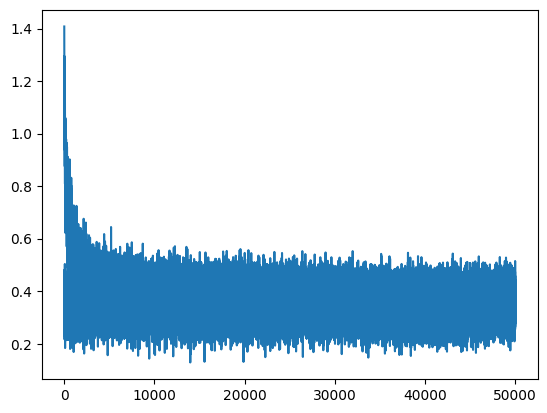

In [166]:
plt.plot(stepi, lossi)

In [167]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1975, grad_fn=<NllLossBackward0>)

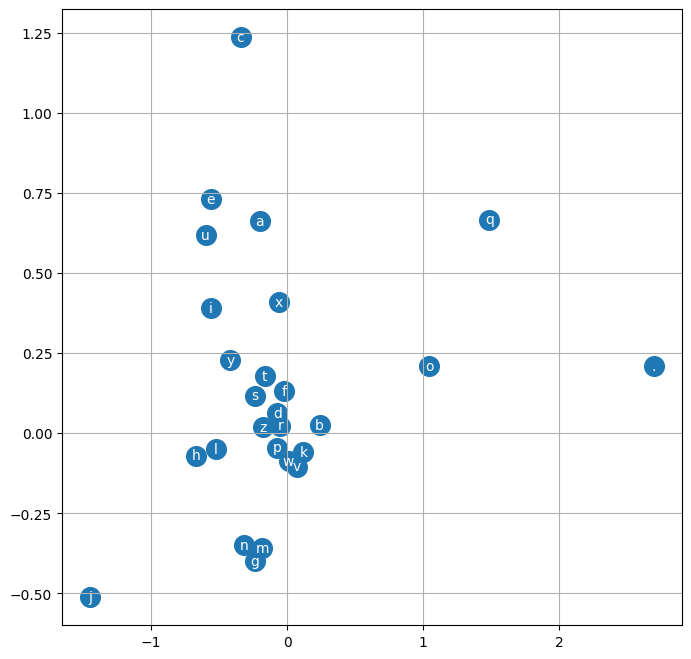

In [168]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i, 0].item(), C[i,  1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [169]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carlah.
ambrilli.
kemley.
taty.
salan.
keja.
hutralee.
art.
kaeli.
nellara.
chaiiv.
kaleigh.
ham.
por.
dessan.
sulin.
alian.
quinaelo.
dearynn.
jaxekiighan.
